In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
def plot_membership_scatter(x_pc, y_pc, p_mem):
    """
    全部观测点，颜色映射隶属概率：黄色=高概率矮星系，深蓝=银河背景
    """
    plt.figure(figsize=(5, 3))
    sc = plt.scatter(x_pc, y_pc, c=p_mem, cmap="plasma", s=6, alpha=0.5)
    plt.colorbar(sc, label=r"Membership Probability $p_{mem}$")
    plt.xlabel("X (pc)")
    plt.ylabel("Y (pc)")
    plt.title("All stars colored by dwarf galaxy membership probability")
    plt.tight_layout()
    plt.show()

def plot_pmem_hist(p_mem):
    # 绘制隶属概率直方图
    plt.figure(figsize=(5, 3))
    plt.hist(p_mem, bins=30, alpha=0.7, color="darkblue", edgecolor="black")
    # 筛选阈值参考线
    plt.axvline(x=0.5, color="red", linestyle="--", label="Threshold = 0.5")
    plt.xlabel("Membership Probability $p_{mem}$")
    plt.ylabel("Number of stars")
    plt.title("Histogram of Dwarf Galaxy Membership Probability")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [27]:
def membership_prob(x_pc, y_pc, f, alpha, mu_x, mu_y, sigma_x, sigma_y):
    range_x = 10000
    range_y = 10000
    dx = x_pc - mu_x
    dy = y_pc - mu_y
    x1 = dx * np.cos(alpha) + dy * np.sin(alpha)
    y1 = dy * np.cos(alpha) - dx * np.sin(alpha)
    log_gauss_single = -np.log(2 * np.pi) - np.log(sigma_x) - np.log(sigma_y) \
                       - 0.5 * (x1**2 / sigma_x**2 + y1**2 / sigma_y**2)
    log_bg_single = -np.log(range_x * range_y)
    log_dw = np.log(f) + log_gauss_single
    log_mw = np.log1p(-f) + log_bg_single
    p_mem = np.exp(log_dw - np.logaddexp(log_dw, log_mw))
    return p_mem

In [28]:
def membership_prob_marginal(x_pc, y_pc, samples):
    N = len(samples)
    total_pmem = np.zeros_like(x_pc)
    range_x, range_y = 10000, 10000
    for k in range(N):
        f, alpha, mu_x, mu_y, sig_x, sig_y, _ = samples[k]
        dx = x_pc - mu_x
        dy = y_pc - mu_y
        x1 = dx * np.cos(alpha) + dy * np.sin(alpha)
        y1 = dy * np.cos(alpha) - dx * np.sin(alpha)
        log_gauss = -np.log(2*np.pi) - np.log(sig_x) - np.log(sig_y) - 0.5*(x1**2/sig_x**2 + y1**2/sig_y**2)
        log_bg = -np.log(range_x * range_y)
        log_dw = np.log(f) + log_gauss
        log_mw = np.log1p(-f) + log_bg
        pmem_k = np.exp(log_dw - np.logaddexp(log_dw, log_mw))
        total_pmem += pmem_k
    avg_pmem = total_pmem / N
    return avg_pmem

In [29]:
def main(data):
    df = pd.read_csv(data)
    name = data.split("/")[-1].split(".")[0]
    samples = pd.read_csv(f"{name}_mcmc.csv")
    f, alpha, mu_x, mu_y, sig_x, sig_y = np.mean(samples, axis=0)[:6]
    x_pc = df["X_pc"].values
    y_pc = df["Y_pc"].values
    p1=membership_prob(x_pc, y_pc, f, alpha, mu_x, mu_y, sig_x, sig_y)   
    p2=membership_prob_marginal(x_pc, y_pc, samples.values)
    plot_membership_scatter(x_pc, y_pc, p1)
    plot_pmem_hist(p1)
    plot_membership_scatter(x_pc, y_pc, p2)
    plot_pmem_hist(p2)

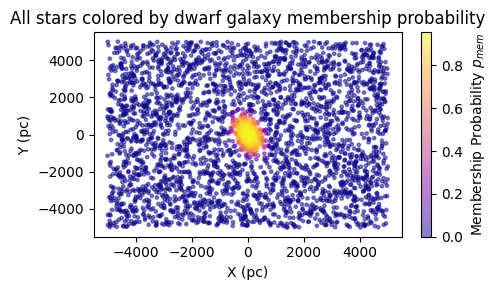

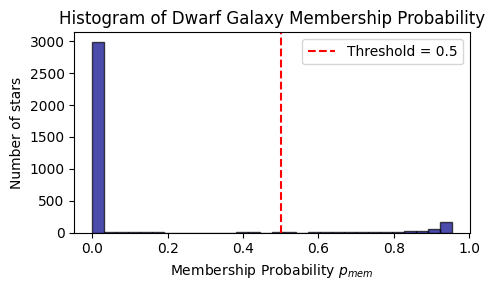

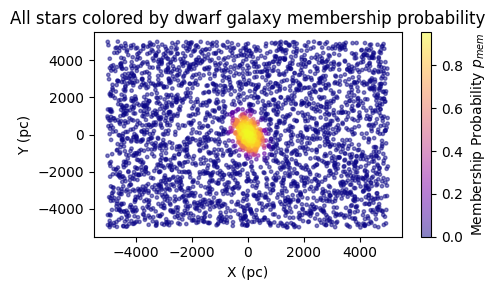

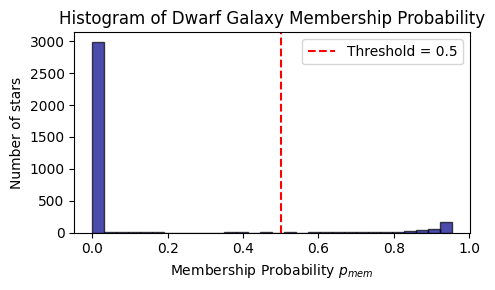

In [30]:
data = "data\Dwarfs\Dwarf_03.csv"
main(data)